In [2]:
import pandas as pd
import numpy as np

# Load dataset
train_og = pd.read_csv("train/subj1_series1_data.csv")
train_events = pd.read_csv("train/subj1_series1_events.csv")

train = pd.merge(train_og, train_events, on="id")

event_dict = {
    "HandStart": 1,
    "FirstDigitTouch": 2, 
    "BothStartLoadPhase": 3,
    "LiftOff": 4,
    "Replace": 5, 
    "BothReleased": 6
}

train["STIM"] = np.zeros((len(train)))

for event, id in event_dict.items():
    train.loc[train[event] == 1, "STIM"] = id

train

,id,Fp1,Fp2,F7,F3,Fz,F4,F8,FC5,FC1,...,Oz,O2,PO10,HandStart,FirstDigitTouch,BothStartLoadPhase,LiftOff,Replace,BothReleased,STIM
0,subj1_series1_0,-31,363,211,121,211,15,717,279,35,...,173,120,704,0,0,0,0,0,0,0.0
1,subj1_series1_1,-29,342,216,123,222,200,595,329,43,...,141,83,737,0,0,0,0,0,0,0.0
2,subj1_series1_2,-172,278,105,93,222,511,471,280,12,...,141,62,677,0,0,0,0,0,0,0.0
3,subj1_series1_3,-272,263,-52,99,208,511,428,261,27,...,139,58,592,0,0,0,0,0,0,0.0
4,subj1_series1_4,-265,213,-67,99,155,380,476,353,32,...,171,67,581,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119491,subj1_series1_119491,478,520,377,172,141,118,-123,626,70,...,-121,-285,-178,0,0,0,0,0,0,0.0
119492,subj1_series1_119492,439,450,298,185,128,502,-331,593,30,...,-152,-295,-178,0,0,0,0,0,0,0.0
119493,subj1_series1_119493,363,370,278,239,124,768,-410,527,16,...,-99,-269,-121,0,0,0,0,0,0,0.0
119494,subj1_series1_119494,281,298,318,257,130,736,-556,542,29,...,-122,-290,-77,0,0,0,0,0,0,0.0


In [3]:
import mne
mne.viz.set_browser_backend('matplotlib')

chnames = list(train_og.columns[1:]) + ["STIM"]
chtypes = ["eeg" for i in chnames]
chtypes[-1] = "stim"
info = mne.create_info(chnames, 500, chtypes)

raw_arr = train[chnames].to_numpy().T * 1e-6
raw_arr[-1] *= 1e6

raw = mne.io.RawArray(raw_arr, info)

raw

Using matplotlib as 2D backend.
Creating RawArray with float64 data, n_channels=33, n_times=119496
    Range : 0 ... 119495 =      0.000 ...   238.990 secs
Ready.


<RawArray | 33 x 119496 (239.0 s), ~30.1 MiB, data loaded>

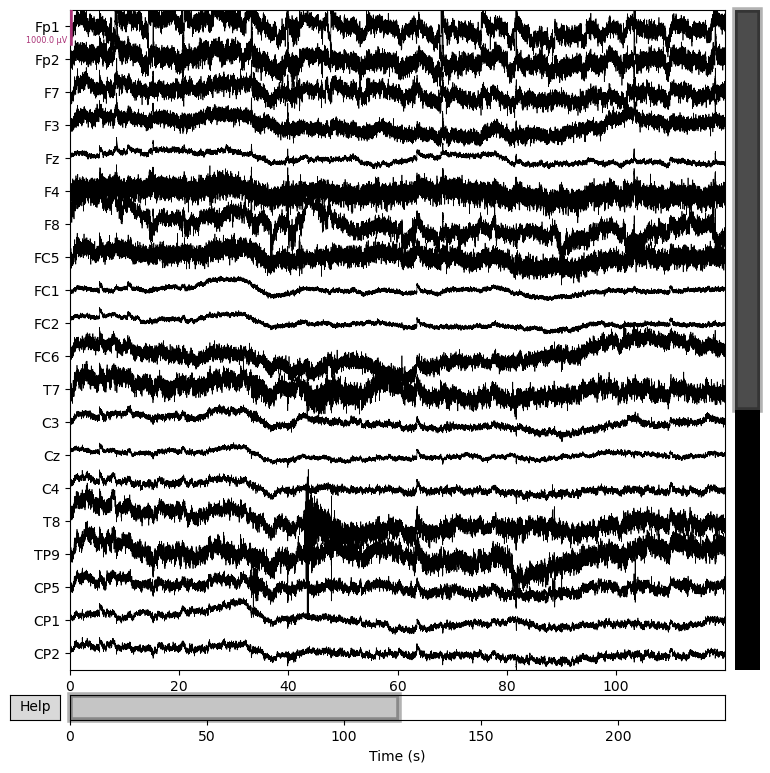

In [4]:
raw.plot(duration=120, scalings=dict(eeg=0.5e-3));

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.20
- Lower transition bandwidth: 0.20 Hz (-6 dB cutoff frequency: 0.10 Hz)
- Filter length: 8251 samples (16.502 s)



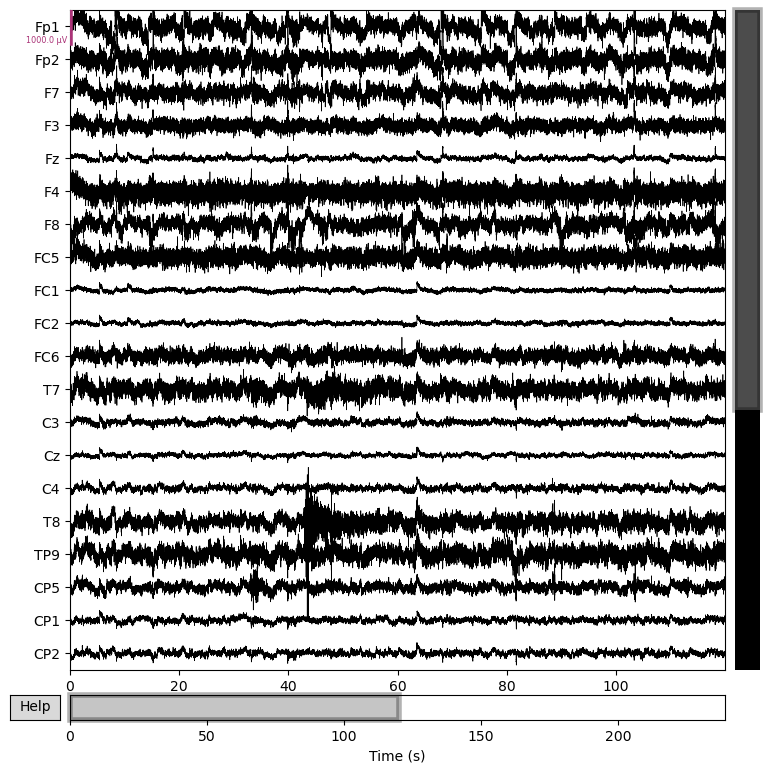

In [5]:
filt_raw = raw.filter(l_freq=0.2, h_freq=None)
filt_raw.plot(duration=120, scalings=dict(eeg=0.5e-3));

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 10 components
Fitting ICA took 1.8s.
Explained variance:
0.041050264834408656
---------
Creating RawArray with float64 data, n_channels=10, n_times=119496
    Range : 0 ... 119495 =      0.000 ...   238.990 secs
Ready.


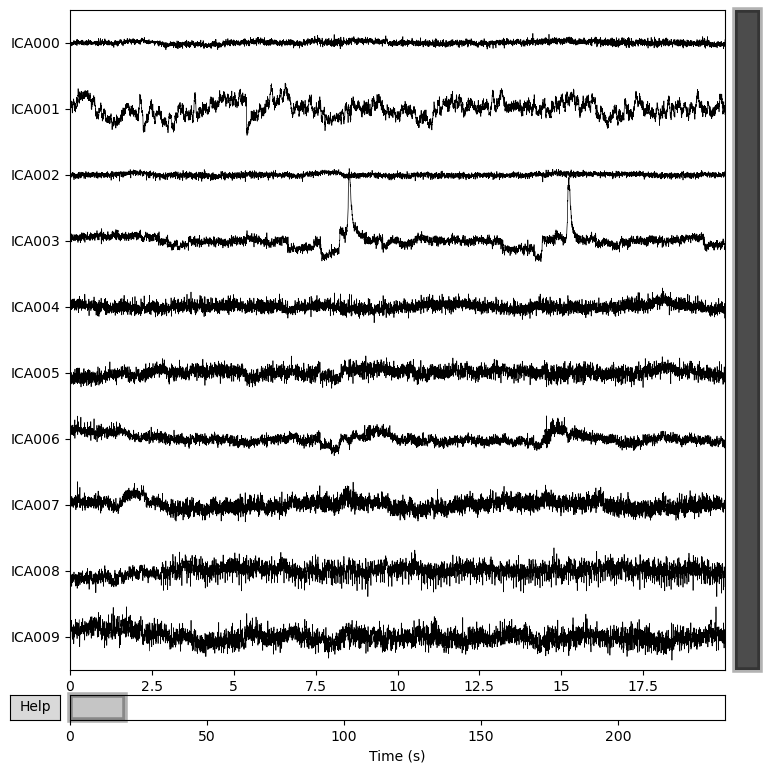

In [6]:
# set up and fit the ICA
ica = mne.preprocessing.ICA(n_components=10, random_state=42, max_iter=800)
ica.fit(filt_raw)

print("Explained variance:")
print(ica.get_explained_variance_ratio(filt_raw, ch_type="eeg", components=[1])["eeg"])
print("---------")

ica.plot_sources(raw);

Applying ICA to Raw instance


    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 32 PCA components


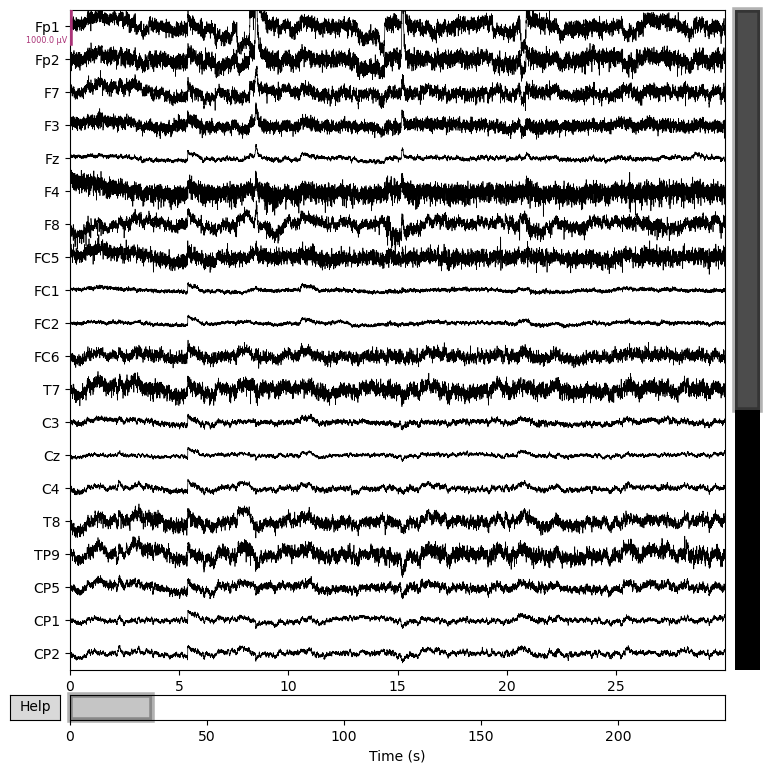

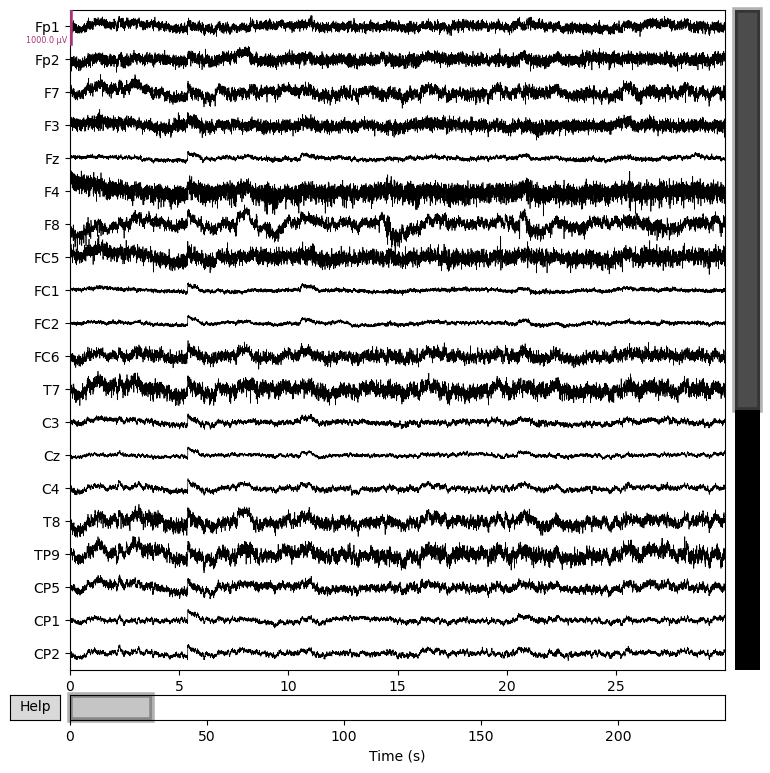

In [7]:
ica.exclude = [3]

reconst_raw = raw.copy()
ica.apply(reconst_raw)

raw.plot(duration=30, scalings=dict(eeg=0.5e-3));
reconst_raw.plot(duration=30, scalings=dict(eeg=0.5e-3));

Finding events on: STIM
204 events found on stim channel STIM
Event IDs: [1 2 3 4 5 6]


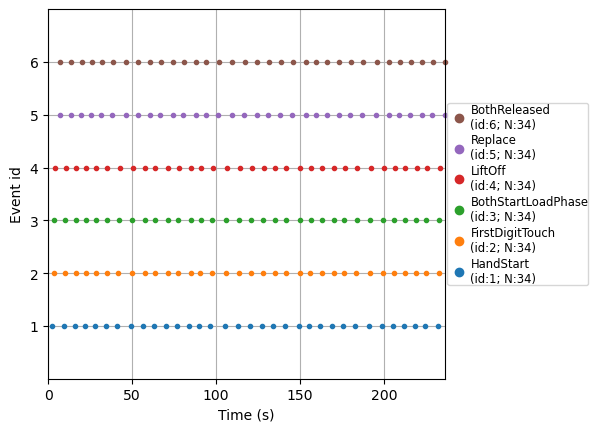

In [8]:
events = mne.find_events(raw, stim_channel="STIM")

fig = mne.viz.plot_events(
    events, event_id=event_dict, sfreq=raw.info["sfreq"], first_samp=raw.first_samp
)

Not setting metadata
204 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 204 events and 501 original time points ...
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['PO10']
    Rejecting  epoch based on EEG : ['PO9']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['F4', 'P7']
    Rejecting  epoch based on EEG : ['F4', 'P7']
    Rejecting  epoch based on EEG : ['F4', 'P7']
    Rejecting  epoch based on EEG : ['CP5', 'TP10', 'P7']
    Rejecting  epoch based on EEG : ['TP10']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F4', 'FC5']
    Rejecting  epoch based on EEG : ['F4', 'FC5']
    Rejecting  epoc

/tmp/ipykernel_280565/1705248957.py:21: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  replace_epochs.plot_image(picks=["Pz", "Cz", "P3", "P4", "Fz"]);
/tmp/ipykernel_280565/1705248957.py:21: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  replace_epochs.plot_image(picks=["Pz", "Cz", "P3", "P4", "Fz"]);
/tmp/ipykernel_280565/1705248957.py:21: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  replace_epochs.plot_image(picks=["Pz", "Cz", "P3", "P4", "Fz"]);
/tmp/ipykernel_280565/1705248957.py:21: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  replace_epochs.plot_image(picks=["Pz", "Cz", "P3", "P4", "Fz"]);
/tmp/ipykernel_280565/1705248957.py:21: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  replace_ep

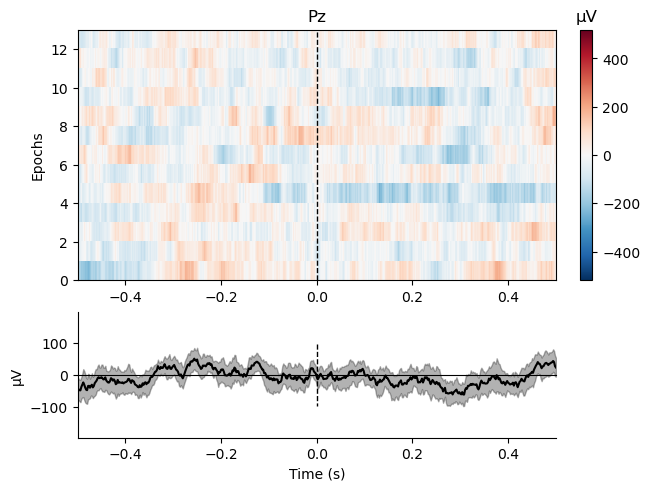

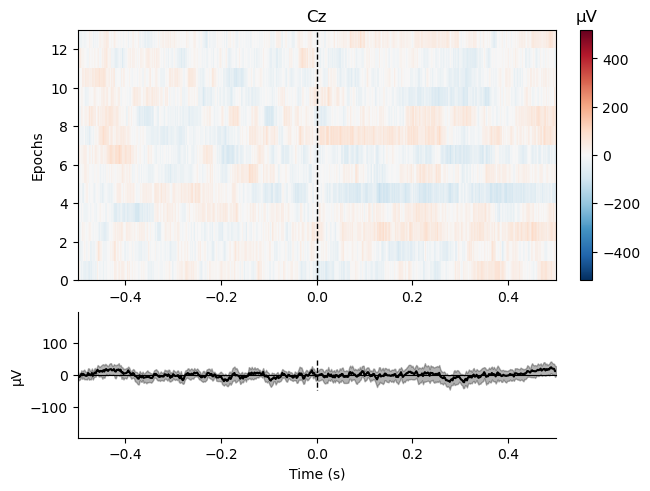

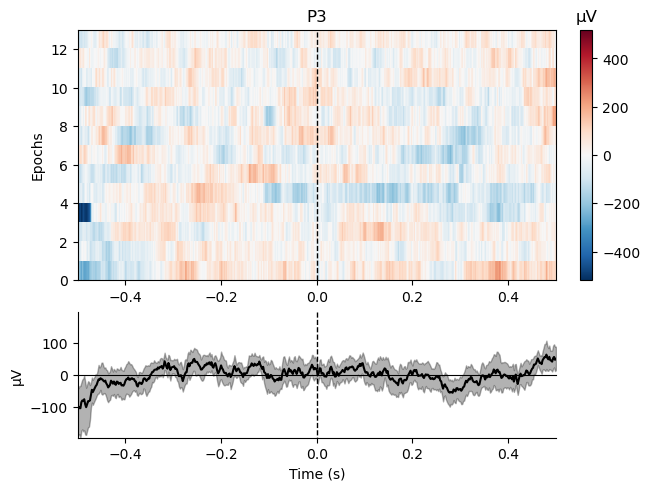

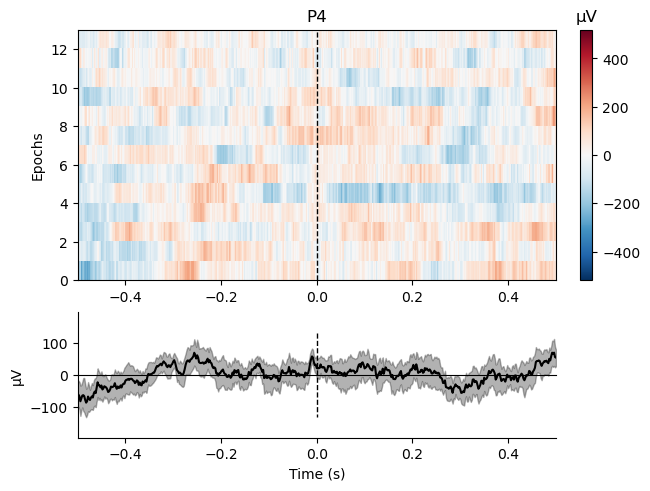

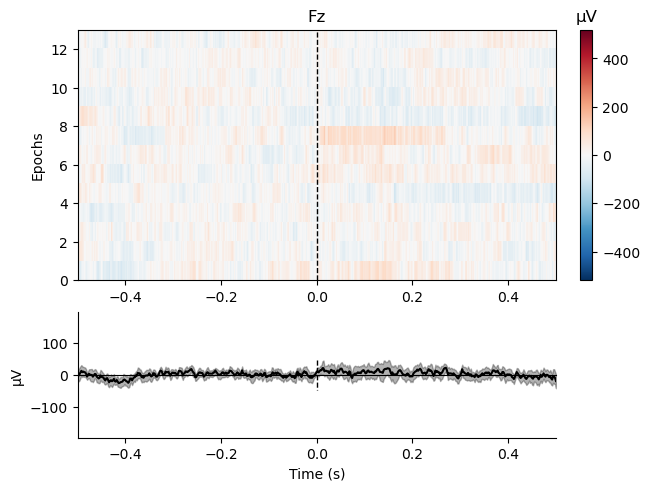

In [9]:
reject_criteria = {"eeg": 1e-3}

epochs = mne.Epochs(
    reconst_raw,
    events,
    event_id=event_dict,
    tmin=-0.5,
    tmax=0.5,
    reject=reject_criteria,
    preload=True,
)

conds_oi = ["LiftOff", "Replace", "HandStart"]

eq_epochs = epochs.copy()
# eq_epochs.equalize_event_counts(conds_oi) 
lift_epochs = eq_epochs["LiftOff"]
replace_epochs = eq_epochs["Replace"]
start_epochs = eq_epochs["HandStart"]

replace_epochs.plot_image(picks=["Pz", "Cz", "P3", "P4", "Fz"]);

In [24]:
X = epochs.get_data(copy=False)[:, :-1, :]
y = epochs.events[:, 2]

print(X.shape)
print(y.shape)

(64, 32, 501)
(64,)


In [ ]:
from mne.decoding import Scaler, Vectorizer, cross_val_multiscore
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

pipeline = make_pipeline(
    Scaler(epochs.info),
    Vectorizer(),
    LogisticRegression()
)

scores = cross_val_multiscore(pipeline, X, y, scoring="accuracy", cv=5, n_jobs=None)

score = np.mean(scores, axis=0)
print(f"{100 * score:0.1f}%")

46.4%
